In [6]:
import numpy as np
import os

%run rom_function.ipynb

### load matrices

In [10]:
for filename in os.listdir("."):
    if filename.endswith(".npy"):
        print(filename)

2q_100000_states_imag.npy
2q_100000_states_labels.npy
2q_100000_states_real.npy


In [17]:
states_real = np.load("2q_100000_states_real.npy", mmap_mode="r")
states_imag = np.load("2q_100000_states_imag.npy", mmap_mode="r")
states_labels = np.load("2q_100000_states_labels.npy", mmap_mode="r")

In [21]:
states_rhos = states_real + 1j * states_imag

In [32]:
roms = []
N = len(states_rhos)
c = 0
checks = set(np.linspace(0, N - 1, 100, dtype=int))
for state_rho in states_rhos:
    if c in checks:
        print(c,'/',N)
    c += 1
    rom = get_rom(state_rho)
    roms.append(rom)

0 / 100000
1010 / 100000
2020 / 100000
3030 / 100000
4040 / 100000
5050 / 100000
6060 / 100000
7070 / 100000
8080 / 100000
9090 / 100000
10100 / 100000
11111 / 100000
12121 / 100000
13131 / 100000
14141 / 100000
15151 / 100000
16161 / 100000
17171 / 100000
18181 / 100000
19191 / 100000
20201 / 100000
21211 / 100000
22222 / 100000
23232 / 100000
24242 / 100000
25252 / 100000
26262 / 100000
27272 / 100000
28282 / 100000
29292 / 100000
30302 / 100000
31312 / 100000
32322 / 100000
33333 / 100000
34343 / 100000
35353 / 100000
36363 / 100000
37373 / 100000
38383 / 100000
39393 / 100000
40403 / 100000
41413 / 100000
42423 / 100000
43433 / 100000
44444 / 100000
45454 / 100000
46464 / 100000
47474 / 100000
48484 / 100000
49494 / 100000
50504 / 100000
51514 / 100000
52524 / 100000
53534 / 100000
54544 / 100000
55555 / 100000
56565 / 100000
57575 / 100000
58585 / 100000
59595 / 100000
60605 / 100000
61615 / 100000
62625 / 100000
63635 / 100000
64645 / 100000
65655 / 100000
66666 / 100000
67676 / 

In [33]:
print(roms)
np.save("rom_labels.npy", roms)

[2.092772321775556, 1.0924205631405737, 1.5685605788603427, 1.731995228677988, 1.8575641848146915, 1.7800388522446156, 2.1523592956364155, 1.444387805648148, 2.100411158055067, 1.8179681040346622, 2.080308679491281, 1.6896927990019337, 1.9858312979340549, 1.2010030746459959, 1.9890008345246315, 2.0159446969628334, 1.6072334945201872, 1.5672322027385237, 1.9150131531059742, 1.3791715428233147, 1.5487903952598572, 1.6418788218870761, 2.1812822074862197, 1.7555565014481547, 1.8404366374015813, 1.992987334728241, 1.8334266580641272, 1.9838745812885468, 2.052280504256487, 1.6577613018453121, 1.9096997659653425, 2.0634275920456275, 1.6002283468842506, 1.7547188683965942, 1.5603362061083317, 2.055898884311317, 2.179333404870704, 2.0823685899376865, 1.8854102473706005, 1.866547517478466, 1.8361951187253, 1.7466044574975963, 1.4518901584669948, 1.2238058889245922, 2.0166193209588528, 1.4278375646099448, 2.0498954802751546, 1.9099509678781033, 0.999999985098839, 1.3634444349445403, 1.48160950466

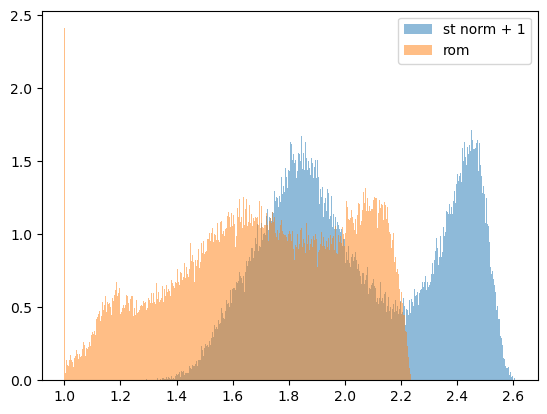

st norm +1 mean:	 2.045078437737778 		 rom norm mean:		 1.7088201779132792
st norm +1 median:	 1.9839392873397594 		 rom norm median:	 1.7227874482050538
st norm +1 std:		 0.3024647878715427 		 rom norm std:		 0.31105328682958994


In [ ]:
from matplotlib import pyplot as plt

plt.hist(states_labels+1, bins=500, density=True, alpha=0.5, label="st norm + 1")
plt.hist(roms, bins=500, density=True, alpha=0.5, label="rom")
plt.legend()
plt.show()
# 数据分布有奇怪的地方，behaviour不统一，kris暂时还没找出来为什么 - rounding errors - false classification to pure states (checks purity) (memory)
# 暂时可以拿去训练 - 先判断后 
# optimization of the parameters and constraints 
# pick meannigful pure states for decompostion

print('st norm +1 mean:\t', np.mean(states_labels+1), '\t\t', 'rom norm mean:\t\t', np.mean(roms))
print('st norm +1 median:\t', np.median(states_labels+1), '\t\t', 'rom norm median:\t', np.median(roms))
print('st norm +1 std:\t\t', np.std(states_labels+1), '\t\t', 'rom norm std:\t\t', np.std(roms))